In [2]:
# autovetores e autovalores

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

#definição

M = np.array([[3., 1.],
              [1., 2.]])

vals, vecs = np.linalg.eigh(M)
print(f"Autovalores {vals}")
print(f"autovetores (colunas): \n {vecs}")

#verificando a definição

for i in range(len(vals)):
    lam = vals[i]
    v = vecs[:, i]
    lhs = M @ v
    rhs = lam * v
    print(f"\nλ={lam:.4f}, v={v}")
    print(f"  M @ v      = {lhs}")
    print(f"  λ * v      = {rhs}")
    print(f"  Idênticos? {np.allclose(lhs, rhs)}")

Autovalores [1.38196601 3.61803399]
autovetores (colunas): 
 [[ 0.52573111 -0.85065081]
 [-0.85065081 -0.52573111]]

λ=1.3820, v=[ 0.52573111 -0.85065081]
  M @ v      = [ 0.72654253 -1.1755705 ]
  λ * v      = [ 0.72654253 -1.1755705 ]
  Idênticos? True

λ=3.6180, v=[-0.85065081 -0.52573111]
  M @ v      = [-3.07768354 -1.90211303]
  λ * v      = [-3.07768354 -1.90211303]
  Idênticos? True


In [3]:
# trabalhando com a equação caracterítica

a_coef, b_coef, c_coef = 1, -5, 5
disc = b_coef**2 - 4*a_coef*c_coef
lam1 = (-b_coef +  np.sqrt(disc))  / (2*a_coef)
lam2 = (-b_coef -  np.sqrt(disc))  / (2*a_coef)

print(f"\nCálculo manual")
print(f"λ₁ = {lam1:.6f}")
print(f"λ₂ = {lam2:.6f}")
print(f"numpy: {sorted(vals)[::-1]}")
print(f"Batem? {np.allclose(sorted([lam1, lam2], reverse=True),
                             sorted(vals, reverse=True))}")

# Propriedades que sempre valem:
print(f"\nTraço (soma da diagonal) = {np.trace(M):.4f}")
print(f"λ₁ + λ₂               = {sum(vals):.4f}  ← sempre iguais")
print(f"\nDeterminante           = {np.linalg.det(M):.4f}")
print(f"λ₁ × λ₂               = {np.prod(vals):.4f}  ← sempre iguais")


Cálculo manual
λ₁ = 3.618034
λ₂ = 1.381966
numpy: [np.float64(3.618033988749895), np.float64(1.381966011250105)]
Batem? True

Traço (soma da diagonal) = 5.0000
λ₁ + λ₂               = 5.0000  ← sempre iguais

Determinante           = 5.0000
λ₁ × λ₂               = 5.0000  ← sempre iguais


In [4]:
# Matrizes simétricas: autovetores sempre ortogonais 
# se M = Mtransposta os autovetores são ortogonais
# como as matrizes de covariancia são sempre simétricas, o PCA sempre encontra direções ortogonais

v1, v2  =  vecs[:, 0], vecs[:, 1]
produto_interno = v1 @ v2
print(f"\nv1 · v2 = {produto_interno:.10f}  <<-- deve ser ≈ 0 (ortogonais)")



v1 · v2 = 0.0000000000  <<-- deve ser ≈ 0 (ortogonais)


In [5]:
# decomposição espectral: M = V Λ Vtransposta

# quando os autovetores formam uma base ortonormal (visto acima) podemos utilizalos para reconstruir a matriz original (da pra pensar alguma coisa com  teorema de godel aqui?)
# depois vamos usar isso para o PCA

Lambda = np.diag(vals) #aquela matriz famosa com os autovalores na diagonal
V = vecs

M_reconstruida = V @ Lambda @ V.T

print(f"\nM original:\n{M}")
print(f"\nV @ Λ @ Vᵀ:\n{np.round(M_reconstruida, 6)}")
print(f"\nIdênticas? {np.allclose(M, M_reconstruida)}")



M original:
[[3. 1.]
 [1. 2.]]

V @ Λ @ Vᵀ:
[[3. 1.]
 [1. 2.]]

Idênticas? True


In [8]:
# mudança de base
np.random.seed(88) #numero da sorte nao falha
n = 300
ang = np.pi / 5
cov_true = M * .8
dados = np.random.multivariate_normal([0, 0], cov_true, n).T

#covariancia empírica
C = np.cov(dados)
print(f"\nCovariância empírica dos dados:\n{np.round(C, 3)}")

# os autovetores da covariancia dão as direçõesde maior variancia
vals_c , vecs_c = np.linalg.eigh(C)
print(f"\nAutovalores da covariância: {vals_c}")
print(f"--> variância em cada direção principal")

#dados projetados nos autovetores
dados_projetados = vecs_c.T @ dados #muda de base

C_proj = np.cov(dados_projetados)
print(f"\nCovariância após projeção nos autovetores:\n{np.round(C_proj, 3)}")
print("--> diagonal! sem correlação. Isso é o PCA.")

# o autovalor diz quanto da informação da em cada direção,
# com isso, se lamda1 >>> lambda2 podemos pegar apenas uma direção sem perder muito e assim começar a comprimir dados

variancia_total = np.sum(vals_c)
for i, (lam, vec) in enumerate(zip(vals_c[::-1], vecs_c.T[::-1])):
    print(f"Direção {i+1}: λ={lam:.3f} → {100*lam/variancia_total:.1f}% da variância")




Covariância empírica dos dados:
[[2.333 0.697]
 [0.697 1.584]]

Autovalores da covariância: [1.16735199 2.7498192 ]
--> variância em cada direção principal

Covariância após projeção nos autovetores:
[[1.167 0.   ]
 [0.    2.75 ]]
--> diagonal! sem correlação. Isso é o PCA.
Direção 1: λ=2.750 → 70.2% da variância
Direção 2: λ=1.167 → 29.8% da variância


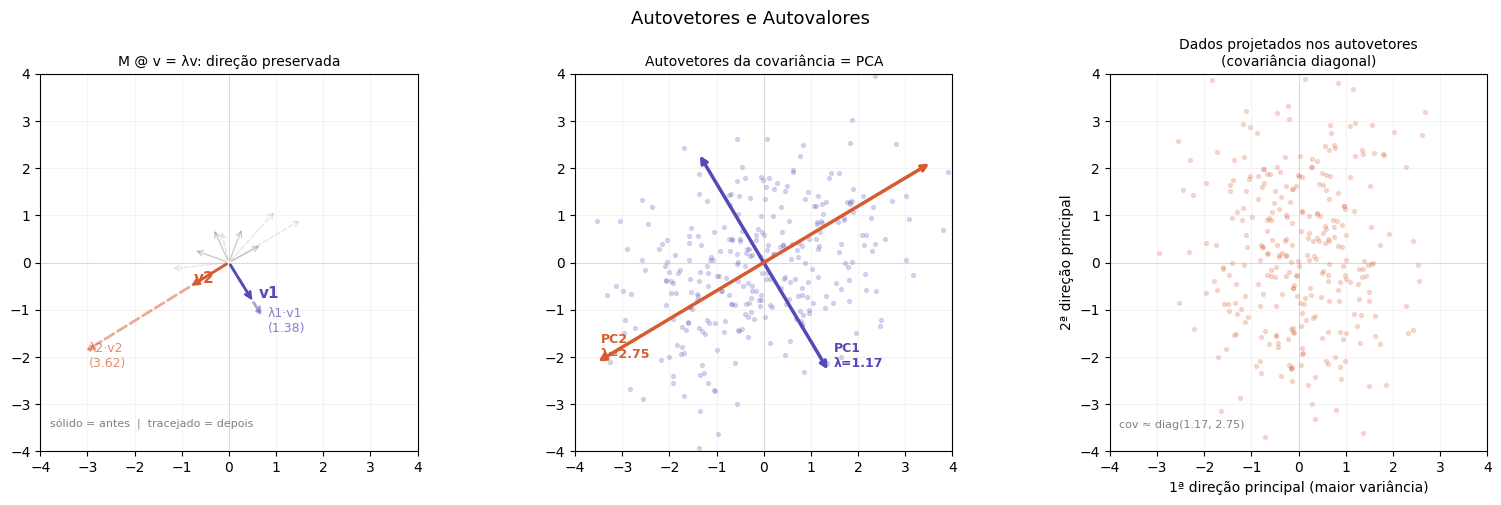

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Autovetores e Autovalores", fontsize=13)

# Plot 1: vetores antes e depois da transformação
ax = axes[0]
ax.set_title("M @ v = λv: direção preservada", fontsize=10)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5, alpha=0.3)
ax.axvline(0, color='gray', lw=0.5, alpha=0.3)
ax.grid(True, alpha=0.15)

cores_eig = ['#534AB7', '#D85A30']
for i in range(2):
    v = vecs[:, i]
    lam = vals[i]
    Mv = M @ v  # = lam * v

    # vetor original
    ax.annotate("", xy=v, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color=cores_eig[i], lw=2))
    # vetor transformado (mesma direção, escala λ)
    ax.annotate("", xy=Mv, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color=cores_eig[i], lw=2,
                       linestyle='dashed', alpha=0.5))
    ax.text(v[0]+0.1, v[1]+0.1, f'v{i+1}', color=cores_eig[i],
            fontsize=11, fontweight='bold')
    ax.text(Mv[0]+0.1, Mv[1]-0.3, f'λ{i+1}·v{i+1}\n({lam:.2f})',
            color=cores_eig[i], fontsize=9, alpha=0.7)

# alguns vetores não-autovetores para contraste
for angulo_v in [0.5, 1.2, 2.0, 2.8]:
    u = np.array([np.cos(angulo_v), np.sin(angulo_v)])
    Mu = M @ u
    ax.annotate("", xy=u*0.8, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.4))
    ax.annotate("", xy=Mu*0.5, xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.2,
                       linestyle='dashed'))

ax.text(-3.8, -3.5, 'sólido = antes  |  tracejado = depois',
        fontsize=8, color='gray')

# --- Plot 2: dados + autovetores da covariância ---
ax2 = axes[1]
ax2.set_title("Autovetores da covariância = PCA", fontsize=10)
ax2.scatter(dados[0], dados[1], alpha=0.2, s=8, color='#534AB7')
ax2.set_xlim(-4, 4); ax2.set_ylim(-4, 4)
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', lw=0.5, alpha=0.3)
ax2.axvline(0, color='gray', lw=0.5, alpha=0.3)
ax2.grid(True, alpha=0.15)

for i in range(2):
    v = vecs_c[:, i]
    lam = vals_c[i]
    escala_v = np.sqrt(lam) * 2.5  # comprimento ∝ desvio padrão
    ax2.annotate("", xy=v*escala_v, xytext=-v*escala_v,
        arrowprops=dict(arrowstyle='<->', color=cores_eig[i], lw=2.5))
    ax2.text(v[0]*escala_v+0.1, v[1]*escala_v+0.1,
             f'PC{i+1}\nλ={lam:.2f}', color=cores_eig[i], fontsize=9,
             fontweight='bold')

# --- Plot 3: dados antes e depois de mudar de base ---
ax3 = axes[2]
ax3.set_title("Dados projetados nos autovetores\n(covariância diagonal)", fontsize=10)
ax3.scatter(dados_projetados[0], dados_projetados[1],
            alpha=0.2, s=8, color='#D85A30')
ax3.set_xlim(-4, 4); ax3.set_ylim(-4, 4)
ax3.set_aspect('equal')
ax3.axhline(0, color='gray', lw=0.5, alpha=0.3)
ax3.axvline(0, color='gray', lw=0.5, alpha=0.3)
ax3.grid(True, alpha=0.15)
ax3.set_xlabel("1ª direção principal (maior variância)")
ax3.set_ylabel("2ª direção principal")

C_str = np.round(np.cov(dados_projetados), 2)
ax3.text(-3.8, -3.5, f'cov ≈ diag({C_str[0,0]}, {C_str[1,1]})',
         fontsize=8, color='gray')

plt.tight_layout()
#plt.savefig('../assets/03_eigenvalues_eigenvectors.png', dpi=150, bbox_inches='tight') 
plt.show()